<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/3.2_RankBasedTests/3.2.6_nonpara_WilcoxonSignRank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependent Samples: The Wilcoxon Sign-Rank Test

The **Wilcoxon Sign-Rank Test** is a rank-based test for the median **difference** in paired samples. It tests whether the median difference between the members of each pair is greater than zero. As such it is often considered to be a non-parametric equivalent for the **paired samples** t-test (which we will meet next week).

Confusingly, The Wilcoxon Sign-rank test is **not** the same as the Wilcoxon Rank Sum test (Mann Whitney U test) which is for independent samples

We will us a Python function called `stats.wilcoxon()` from the `scipy.stats` library to run the test

## Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [2]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.simplefilter('ignore', category=FutureWarning)

## Example: birth order and independence

It has been argued that birth order in families affects how independent individuals are as adults - either that first-born children tend to be more independent than later born children or vice versa.

In a (fictional) study, 20 sibling pairs are recruited, each consisting of a **first-born** and a **second-born** child. All participants are young adults and are interviewed at the age of 21. For each participant, the researcher records an **independence score** on a 25-point scale, where higher scores indicate greater independence. Scores are based on a structured interview.

**Question:** test whether there is a difference in independence scores between first-born and second-born children.

*Notes:*
- This is a **paired-samples** design: each first-born participant is naturally paired with a second-born participant from the same family.
- The outcome variable (independence score) is bounded and may not be Normally distributed, so the Normality assumption for a paired-samples t-test may not hold (but you should inspect the data to assess this).
- A rank-based test such as the **Wilcoxon signed-rank** test is a suitable choice. It tests for a difference in the median of the paired differences and is robust to non-Normality and outliers.
- Decide whether you want a **one-sided** or **two-sided** test.

*Practical steps*
1. Inspect the data (e.g. paired plots, histograms of differences) for skewness and outliers.  
2. State the formal hypotheses.  
3. Report the descriptive statistics (e.g. medians of each group and/or the median difference).  
4. Run the Wilcoxon signed-rank test.  
5. Draw conclusions.

### 1. Inspect the data

The data are provided in a text (.csv) file.

Let's load the data as a Pandas dataframe, and plot them to get a sense for their distribution (is it normal?) and any outliers


In [3]:
# load the data and have a look
birthOrder = pd.read_csv('https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/data/BirthOrderIndependence.csv')
birthOrder

,FirstBorn,SecondBorn
0,12,10
1,18,12
2,13,15
3,17,13
4,8,9
5,15,12
6,16,13
7,5,8
8,8,10
9,12,8


Let's plot the data to get an idea of the distribution and check for outliers.

In the case of paired data, the most effective way to get a sense of the data is a scatterplot:

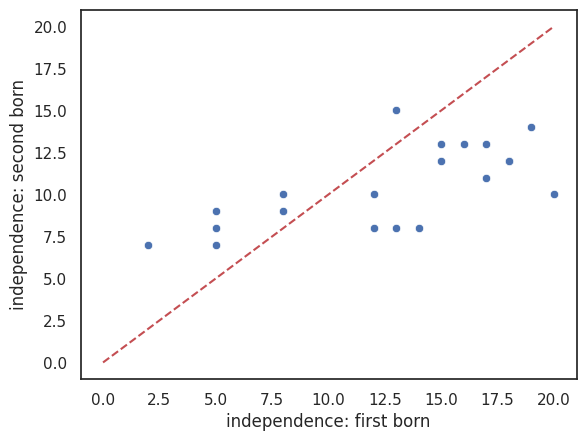

In [4]:
sns.scatterplot(data = birthOrder, x="FirstBorn", y="SecondBorn")
plt.xlabel("independence: first born")
plt.ylabel("independence: second born")

# add the line x=y (ie a line from point(50,50) to (110,110)) for reference
plt.plot([0,20],[0,20],'r--')

Comments:

- There is some correlation in independence between first- and second-born siblings (families with more independent first-borns also tend to have more independent second-borns, maybe not surprising, but also not what we want to test now...).
- There are slightly more sibling pairs in which the first-born is more independent than the second-born (points lying below the line $(x = y)$).
- It appears that in families with higher independence scores, the first-born tends to be more independent than the second-born, whereas in families with


### Check the data distribution

In the case of paired data, we are interested in the distribution of *differences* within pairs. (not the distributions themselves)

Let's add a column to our dataframe to contain the differences

In [5]:
birthOrder['Diff'] = birthOrder.FirstBorn - birthOrder.SecondBorn
birthOrder

,FirstBorn,SecondBorn,Diff
0,12,10,2
1,18,12,6
2,13,15,-2
3,17,13,4
4,8,9,-1
5,15,12,3
6,16,13,3
7,5,8,-3
8,8,10,-2
9,12,8,4


Now let's plot the differences to get a sense of whether they are normally distributed.

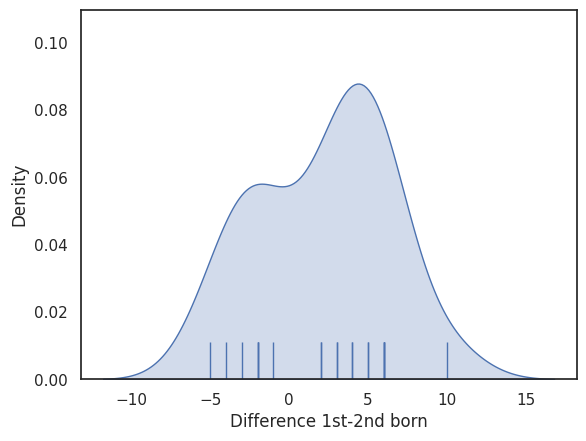

In [6]:
sns.kdeplot(data=birthOrder, x='Diff',  color='b', fill=True)
sns.rugplot(data=birthOrder, x='Diff', height=0.1, color='b')
plt.xlabel('Difference 1st-2nd born')
plt.show()

The distribution has a slight hint of bimodaility (two-peaks) although it can be tough to tell with so few samples.

### 2. Hypotheses

$\mathcal{H_o}$: the median difference in independence between first- and second-born siblings is is zero

$\mathcal{H_a}$: the median difference in independence is not zero
    
This is a two-tailed test as the researcher's hypothesis (described above) is not directional.

We will test at the $\alpha = 0.05$ significance level

* note we are testing for a difference of medians here, not a difference of means!

### 3. Descriptive statistics

Next we need to obtain some relevant descriptive statistics.

Since we are testing for a difference of medians, we will want the median for each group; it would also be useful to have a measure of spread, and the sample size. `df.describe()` should do the trick!

In [7]:
birthOrder.describe()

,FirstBorn,SecondBorn,Diff
count,20.000000,20.000000,20.000000
mean,12.600000,10.450000,2.150000
std,5.364601,2.438183,4.120232
min,2.000000,7.000000,-5.000000
25%,8.000000,8.000000,-2.000000
50%,13.500000,10.000000,3.000000
75%,17.000000,12.250000,5.250000
max,20.000000,15.000000,10.000000


- **FirstBorn:** median = 13.5, Q1 = 8, Q3 = 17, \(n = 20\)  
- **SecondBorn:** median = 10, Q1 = 8, Q3 = 12.25, \(n = 20\)


### 4. Carry out the test

We carry out the test using the function `stats.wilcoxon()` from `scipy.stats`.

The inputs to `stats.mannwhitneyu()` are:
* the two samples to be compared (the values of <tt>FirstBorn</tt> and <tt>SecondBorn</tt> from our Pandas data frame <tt>birthOrder</tt>)
* the argument `alternative='two-sided'`, which tells the computer to run a two tailed test  that median of the first input (FirstBorn) is greater than the second (SecondBorn).

The outputs are a value of the test statistic ($T=46$) and <tt>pvalue</tt> ($p=0.0266$) - if this is less than our $\alpha$ value 0.5, there is a significant difference.

More explanation of how T is calculated below.

In [8]:
stats.wilcoxon(birthOrder.FirstBorn,birthOrder.SecondBorn,alternative='two-sided')


WilcoxonResult(statistic=np.float64(46.0), pvalue=np.float64(0.0270545122779512))

### 5. Draw conclusions


Because the <tt>pvalue</tt> ($p=0.02705$) is less than our chosen significance level ($\alpha = 0.05$), the test is considered statistically significant.

We therefore conclude that the median difference in independence is greater **First Borns** compared to the **Second Borns**

### How the Wilcoxon Sign-Rank test works

The mechanism of the test but is similar in principle to the ranksum test, except that here we work with ranked *differences*.


### How to do the test (if you were doing it with pencil and paper)

1. Compute the difference in independence score for each sibling pair.

2. Remove any pairs with a difference of zero. Rank the differences **by their absolute value**, ignoring the sign (for example, a difference of +4 has a larger rank than −3, which has a larger rank than +2).

3. Calculate the sum of ranks for pairs with a **positive** difference (first-born more independent than second-born). This is denoted $R^+$.

4. Calculate the sum of ranks for pairs with a **negative** difference (second-born more independent than first-born). This is denoted $R^-$.

5. Define the test statistic $T$ as follows:
   - $T = R^+$ if we expect positive differences to receive the larger ranks (in this case, if we expect first-borns to have higher independence scores);
   - $T = R^-$ if we expect negative differences to receive the larger ranks (i.e. if we expect second-borns to have higher independence scores);
   - for a **two-tailed** test, $T$ is the smaller of $R^+$ and $R^-$ (as in this example, where we have no *a priori* hypothesis about the direction of the effect).

6. Compare the observed value of $T$ with its null distribution (the distribution of $T$ expected for samples drawn from a population in which there is no true difference between the paired measurements).

We will not build code to carry out these steps here. However, if you are feeling adventurous, you are welcome to try implementing the procedure yourself, using the between-groups rank-sum test as a model.
